## Model Training

In [4]:
import pandas as pd

# load all
students = pd.read_csv("D:/intelligent-erp-analytics/data/anonymisedData/studentInfo.csv")
assessments = pd.read_csv("D:/intelligent-erp-analytics/data/anonymisedData/assessments.csv")
student_assess = pd.read_csv("D:/intelligent-erp-analytics/data/anonymisedData/studentAssessment.csv")

# STEP 1: merge student + studentAssessment
df = students.merge(student_assess, on="id_student")

# STEP 2: merge with assessments (on id_assessment)
df = df.merge(assessments, on="id_assessment")

# STEP 3: clean target
df["final_result"] = df["final_result"].map({
    "Pass": 1,
    "Fail": 0,
    "Distinction": 1,
    "Withdrawn": 0
})

print(df.head())

  code_module_x code_presentation_x  id_student gender               region  \
0           AAA               2013J       11391      M  East Anglian Region   
1           AAA               2013J       11391      M  East Anglian Region   
2           AAA               2013J       11391      M  East Anglian Region   
3           AAA               2013J       11391      M  East Anglian Region   
4           AAA               2013J       11391      M  East Anglian Region   

  highest_education imd_band age_band  num_of_prev_attempts  studied_credits  \
0  HE Qualification  90-100%     55<=                     0              240   
1  HE Qualification  90-100%     55<=                     0              240   
2  HE Qualification  90-100%     55<=                     0              240   
3  HE Qualification  90-100%     55<=                     0              240   
4  HE Qualification  90-100%     55<=                     0              240   

   ... final_result  id_assessment  date_sub

In [5]:
features = df[[
    "num_of_prev_attempts",
    "studied_credits",
    "score",
    "weight"
]]

target = df["final_result"]

In [6]:
student_vle = pd.read_csv(
    "D:/intelligent-erp-analytics/data/anonymisedData/studentVle.csv"
)

engagement = (
    student_vle
    .groupby("id_student")["sum_click"]
    .sum()
    .reset_index()
)

df = df.merge(engagement, on="id_student", how="left")

print(df.head())

  code_module_x code_presentation_x  id_student gender               region  \
0           AAA               2013J       11391      M  East Anglian Region   
1           AAA               2013J       11391      M  East Anglian Region   
2           AAA               2013J       11391      M  East Anglian Region   
3           AAA               2013J       11391      M  East Anglian Region   
4           AAA               2013J       11391      M  East Anglian Region   

  highest_education imd_band age_band  num_of_prev_attempts  studied_credits  \
0  HE Qualification  90-100%     55<=                     0              240   
1  HE Qualification  90-100%     55<=                     0              240   
2  HE Qualification  90-100%     55<=                     0              240   
3  HE Qualification  90-100%     55<=                     0              240   
4  HE Qualification  90-100%     55<=                     0              240   

   ... id_assessment  date_submitted  is_ban

In [7]:
df["sum_click"] = df["sum_click"].fillna(0)

In [8]:
features = df[[
    "num_of_prev_attempts",
    "studied_credits",
    "score",
    "weight",
    "sum_click"
]]

target = df["final_result"]

In [9]:
student_df = df.groupby("id_student").agg({
    "num_of_prev_attempts": "first",
    "studied_credits": "first",
    "score": "mean",          # avg performance
    "weight": "sum",          # total weight attempted
    "sum_click": "first",     # engagement
    "final_result": "first"   # target
}).reset_index()

print(student_df.head())

   id_student  num_of_prev_attempts  studied_credits      score  weight  \
0        6516                     0               60  61.800000   100.0   
1        8462                     0               90  87.000000   180.0   
2       11391                     0              240  82.000000   100.0   
3       23629                     2               60  82.500000    25.0   
4       23698                     0              120  74.444444   200.0   

   sum_click  final_result  
0     2791.0             1  
1      656.0             0  
2      934.0             1  
3      161.0             0  
4      910.0             1  


In [10]:
student_df = df.groupby("id_student").agg({
    "num_of_prev_attempts": "first",
    "studied_credits": "first",
    "score": "mean",          # avg performance
    "weight": "sum",          # total weight attempted
    "sum_click": "first",     # engagement
    "final_result": "first"   # target
}).reset_index()

print(student_df.head())

   id_student  num_of_prev_attempts  studied_credits      score  weight  \
0        6516                     0               60  61.800000   100.0   
1        8462                     0               90  87.000000   180.0   
2       11391                     0              240  82.000000   100.0   
3       23629                     2               60  82.500000    25.0   
4       23698                     0              120  74.444444   200.0   

   sum_click  final_result  
0     2791.0             1  
1      656.0             0  
2      934.0             1  
3      161.0             0  
4      910.0             1  


In [11]:
student_df = df.groupby("id_student").agg({
    "num_of_prev_attempts": "first",
    "studied_credits": "first",
    "score": "mean",
    "weight": "sum",
    "sum_click": "first",
    "final_result": "first"
}).reset_index()

In [12]:
student_df["engagement_per_credit"] = (
    student_df["sum_click"] / student_df["studied_credits"]
)

student_df["performance_index"] = (
    student_df["score"] * student_df["weight"] / 100
)

In [13]:
features = student_df[[
    "num_of_prev_attempts",
    "studied_credits",
    "score",
    "weight",
    "sum_click",
    "engagement_per_credit",
    "performance_index"
]]

target = student_df["final_result"]

In [14]:
print(student_df.columns)

Index(['id_student', 'num_of_prev_attempts', 'studied_credits', 'score',
       'weight', 'sum_click', 'final_result', 'engagement_per_credit',
       'performance_index'],
      dtype='object')


In [15]:
student_df["engagement_per_credit"] = (
    student_df["sum_click"] / (student_df["studied_credits"] + 1)
)

In [16]:
student_df.to_csv(
    "D:/intelligent-erp-analytics/backend/app/ml_models/processed_student_data.csv",
    index=False
)

In [17]:
print(student_df.isnull().sum())

id_student                0
num_of_prev_attempts      0
studied_credits           0
score                    18
weight                    0
sum_click                 0
final_result              0
engagement_per_credit     0
performance_index        18
dtype: int64


In [18]:
# fill score first
student_df["score"] = student_df["score"].fillna(student_df["score"].mean())

# recompute everything cleanly
student_df["performance_index"] = (
    student_df["score"] * student_df["weight"] / 100
)

student_df.to_csv(
    "D:/intelligent-erp-analytics/backend/app/ml_models/processed_student_data.csv",
    index=False
)

In [19]:
import pandas as pd
import joblib

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score

# models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier

# =========================
# LOAD DATA (your prepared student_df)
# =========================

df = pd.read_csv(
    "D:/intelligent-erp-analytics/backend/app/ml_models/processed_student_data.csv"
)

features = df[[
    "num_of_prev_attempts",
    "studied_credits",
    "score",
    "weight",
    "sum_click",
    "engagement_per_credit",
    "performance_index"
]]

target = df["final_result"]

# =========================
# SPLIT
# =========================

X_train, X_test, y_train, y_test = train_test_split(
    features, target, test_size=0.2, random_state=42
)

# =========================
# MODELS DICTIONARY
# =========================

models = {
    "logistic": LogisticRegression(max_iter=1000),
    "random_forest": RandomForestClassifier(n_estimators=100, max_depth=5),
    "svm": SVC(probability=True),
    "knn": KNeighborsClassifier(n_neighbors=5),
    "xgboost": XGBClassifier(use_label_encoder=False, eval_metric="logloss")
}

results = []

# =========================
# TRAIN LOOP
# =========================

for name, model in models.items():
    print(f"\nTraining {name}...")

    model.fit(X_train, y_train)

    preds = model.predict(X_test)

    acc = accuracy_score(y_test, preds)
    f1 = f1_score(y_test, preds)

    print(f"{name} → Accuracy: {acc:.4f}, F1: {f1:.4f}")

    # save model
    joblib.dump(model, f"saved_models/model_{name}.pkl")

    results.append({
        "model": name,
        "accuracy": acc,
        "f1_score": f1
    })



Training logistic...
logistic → Accuracy: 0.7336, F1: 0.7789

Training random_forest...
random_forest → Accuracy: 0.8778, F1: 0.8995

Training svm...
svm → Accuracy: 0.7377, F1: 0.7901

Training knn...
knn → Accuracy: 0.8393, F1: 0.8673

Training xgboost...


C:\Users\inafe\miniconda3\envs\pyv3\lib\site-packages\xgboost\core.py:158: UserWarning: [07:55:11] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


xgboost → Accuracy: 0.8783, F1: 0.8977


In [20]:
# =========================
# SAVE RESULTS
# =========================

results_df = pd.DataFrame(results)
results_df.to_csv("reports/results.csv", index=False)

print("\nAll models trained and saved")


All models trained and saved


ft re

In [21]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [5, 10, None],
    "min_samples_split": [2, 5]
}

grid_rf = GridSearchCV(
    RandomForestClassifier(),
    param_grid,
    cv=3,
    scoring="f1",
    n_jobs=-1
)

grid_rf.fit(X_train, y_train)

print("Best RF:", grid_rf.best_params_)

Best RF: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 100}


In [23]:
param_grid_xgb = {
    "n_estimators": [100, 200],
    "max_depth": [3, 5, 7],
    "learning_rate": [0.01, 0.1]
}

grid_xgb = GridSearchCV(
    XGBClassifier(eval_metric="logloss"),
    param_grid_xgb,
    cv=3,
    scoring="f1",
    n_jobs=-1
)

grid_xgb.fit(X_train, y_train)

print("Best XGB:", grid_xgb.best_params_)

Best XGB: {'learning_rate': 0.01, 'max_depth': 7, 'n_estimators': 100}


In [25]:
import joblib
import pandas as pd

from sklearn.metrics import accuracy_score, f1_score, classification_report

# =========================
# BEST MODELS
# =========================

best_rf = grid_rf.best_estimator_
best_xgb = grid_xgb.best_estimator_

# =========================
# PREDICTIONS
# =========================

rf_preds = best_rf.predict(X_test)
xgb_preds = best_xgb.predict(X_test)

# =========================
# METRICS
# =========================

rf_acc = accuracy_score(y_test, rf_preds)
rf_f1 = f1_score(y_test, rf_preds)

xgb_acc = accuracy_score(y_test, xgb_preds)
xgb_f1 = f1_score(y_test, xgb_preds)

print("\n===== RANDOM FOREST (TUNED) =====")
print("Accuracy:", rf_acc)
print("F1 Score:", rf_f1)
print(classification_report(y_test, rf_preds))

print("\n===== XGBOOST (TUNED) =====")
print("Accuracy:", xgb_acc)
print("F1 Score:", xgb_f1)
print(classification_report(y_test, xgb_preds))


===== RANDOM FOREST (TUNED) =====
Accuracy: 0.8833975181857082
F1 Score: 0.9028347298983777
              precision    recall  f1-score   support

           0       0.92      0.80      0.85      2004
           1       0.86      0.95      0.90      2670

    accuracy                           0.88      4674
   macro avg       0.89      0.87      0.88      4674
weighted avg       0.89      0.88      0.88      4674


===== XGBOOST (TUNED) =====
Accuracy: 0.8821138211382114
F1 Score: 0.9029758760345131
              precision    recall  f1-score   support

           0       0.94      0.78      0.85      2004
           1       0.85      0.96      0.90      2670

    accuracy                           0.88      4674
   macro avg       0.89      0.87      0.88      4674
weighted avg       0.89      0.88      0.88      4674



In [26]:
# =========================
# SAVE MODELS
# =========================

joblib.dump(best_rf, "D:/intelligent-erp-analytics/backend/app/ml_models/saved_models/model_rf_tuned.pkl")
joblib.dump(best_xgb, "D:/intelligent-erp-analytics/backend/app/ml_models/saved_models/model_xgb_tuned.pkl")

print("\nModels saved successfully")


Models saved successfully


In [29]:
results = pd.DataFrame([
    {"model": "RandomForest_Tuned", "accuracy": rf_acc, "f1_score": rf_f1},
    {"model": "XGBoost_Tuned", "accuracy": xgb_acc, "f1_score": xgb_f1}
])

results.to_csv("D:/intelligent-erp-analytics/backend/app/ml_models/reports/tuned_results.csv", index=False)

print("Metrics saved to CSV")

Metrics saved to CSV


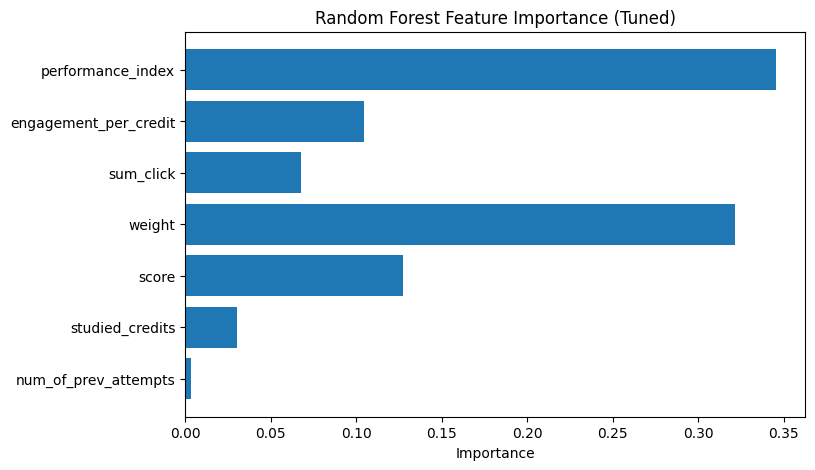

In [30]:
import matplotlib.pyplot as plt

rf_importance = best_rf.feature_importances_

plt.figure(figsize=(8,5))
plt.barh(features.columns, rf_importance)
plt.title("Random Forest Feature Importance (Tuned)")
plt.xlabel("Importance")
plt.show()

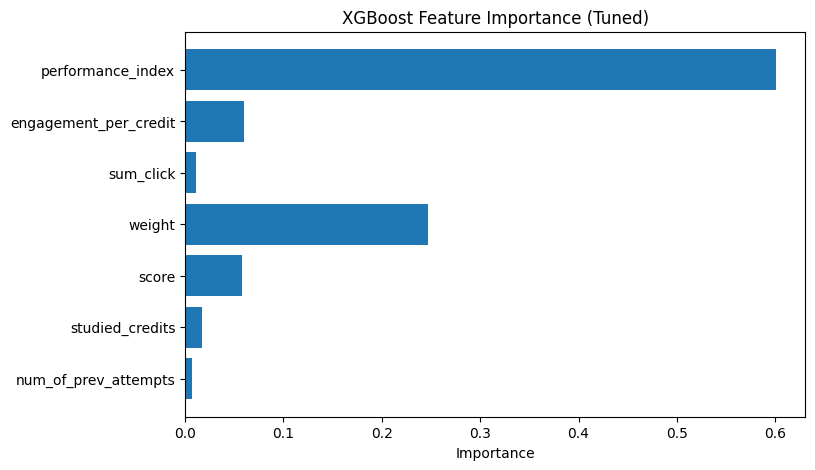

In [31]:
xgb_importance = best_xgb.feature_importances_

plt.figure(figsize=(8,5))
plt.barh(features.columns, xgb_importance)
plt.title("XGBoost Feature Importance (Tuned)")
plt.xlabel("Importance")
plt.show()

In [32]:
rf_imp_df = pd.DataFrame({
    "feature": features.columns,
    "importance": rf_importance
}).sort_values(by="importance", ascending=False)

xgb_imp_df = pd.DataFrame({
    "feature": features.columns,
    "importance": xgb_importance
}).sort_values(by="importance", ascending=False)

rf_imp_df.to_csv("D:/intelligent-erp-analytics/backend/app/ml_models/reports/rf_feature_importance.csv", index=False)
xgb_imp_df.to_csv("D:/intelligent-erp-analytics/backend/app/ml_models/reports/xgb_feature_importance.csv", index=False)

print("Feature importance saved")

Feature importance saved



===== RANDOM FOREST (BALANCED) =====
Accuracy: 0.8737697903294822
F1 Score: 0.8889307228915663
              precision    recall  f1-score   support

           0       0.85      0.86      0.85      2004
           1       0.89      0.88      0.89      2670

    accuracy                           0.87      4674
   macro avg       0.87      0.87      0.87      4674
weighted avg       0.87      0.87      0.87      4674


===== XGBOOST (BALANCED) =====
Accuracy: 0.8575096277278562
F1 Score: 0.8710302091402014
              precision    recall  f1-score   support

           0       0.81      0.88      0.84      2004
           1       0.90      0.84      0.87      2670

    accuracy                           0.86      4674
   macro avg       0.85      0.86      0.86      4674
weighted avg       0.86      0.86      0.86      4674


Cross Validation F1 Scores: [0.89640131 0.89575845 0.8838871  0.89795918 0.91144243]
Mean CV F1 Score: 0.8970896941165091


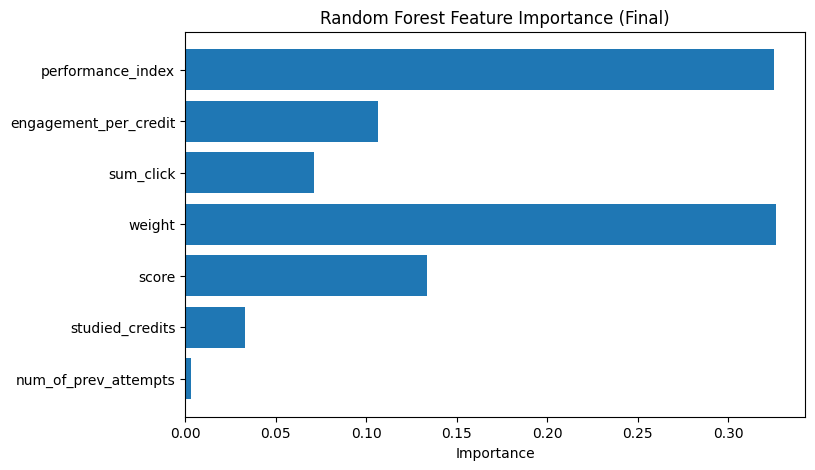


Final models saved successfully

Sample Risk Level: Medium Risk


In [33]:
import pandas as pd
import joblib
import numpy as np

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# =========================
# LOAD DATA
# =========================

df = pd.read_csv("processed_student_data.csv")

features = df[[
    "num_of_prev_attempts",
    "studied_credits",
    "score",
    "weight",
    "sum_click",
    "engagement_per_credit",
    "performance_index"
]]

target = df["final_result"]

# =========================
# TRAIN TEST SPLIT
# =========================

X_train, X_test, y_train, y_test = train_test_split(
    features, target, test_size=0.2, random_state=42
)

# =========================
# RANDOM FOREST (BALANCED)
# =========================

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=5,
    class_weight="balanced",
    random_state=42
)

rf_model.fit(X_train, y_train)

# =========================
# XGBOOST (BALANCED)
# =========================

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=7,
    learning_rate=0.01,
    scale_pos_weight=scale_pos_weight,
    eval_metric="logloss"
)

xgb_model.fit(X_train, y_train)

# =========================
# PREDICTIONS WITH THRESHOLD
# =========================

threshold = 0.6

rf_probs = rf_model.predict_proba(X_test)[:, 1]
rf_preds = (rf_probs > threshold).astype(int)

xgb_probs = xgb_model.predict_proba(X_test)[:, 1]
xgb_preds = (xgb_probs > threshold).astype(int)

# =========================
# METRICS
# =========================

print("\n===== RANDOM FOREST (BALANCED) =====")
print("Accuracy:", accuracy_score(y_test, rf_preds))
print("F1 Score:", f1_score(y_test, rf_preds))
print(classification_report(y_test, rf_preds))

print("\n===== XGBOOST (BALANCED) =====")
print("Accuracy:", accuracy_score(y_test, xgb_preds))
print("F1 Score:", f1_score(y_test, xgb_preds))
print(classification_report(y_test, xgb_preds))

# =========================
# CROSS VALIDATION
# =========================

cv_scores = cross_val_score(rf_model, features, target, cv=5, scoring="f1")

print("\nCross Validation F1 Scores:", cv_scores)
print("Mean CV F1 Score:", cv_scores.mean())

# =========================
# FEATURE IMPORTANCE
# =========================

import matplotlib.pyplot as plt

rf_importance = rf_model.feature_importances_

plt.figure(figsize=(8,5))
plt.barh(features.columns, rf_importance)
plt.title("Random Forest Feature Importance (Final)")
plt.xlabel("Importance")
plt.show()

# =========================
# SAVE MODELS
# =========================

joblib.dump(rf_model, "D:/intelligent-erp-analytics/backend/app/ml_models/saved_models/model_rf_final.pkl")
joblib.dump(xgb_model, "D:/intelligent-erp-analytics/backend/app/ml_models/saved_models/model_xgb_final.pkl")

print("\nFinal models saved successfully")

# =========================
# RISK FUNCTION (FOR API)
# =========================

def get_risk(prob):
    if prob < 0.4:
        return "High Risk"
    elif prob < 0.7:
        return "Medium Risk"
    else:
        return "Low Risk"


# Example usage
sample_prob = rf_probs[0]
print("\nSample Risk Level:", get_risk(sample_prob))

In [2]:
import pickle

file_path = 'D:/intelligent-erp-analytics/backend/app/ml_models/saved_models/model_xgb_final.pkl'

try:
    with open(file_path, 'rb') as file:
        model = pickle.load(file)
    
    print("Model loaded successfully!")

except FileNotFoundError:
    print(f"Error: The file '{file_path}' was not found.")
except Exception as e:
    print(f"An error occurred while loading the model: {e}")


Model loaded successfully!


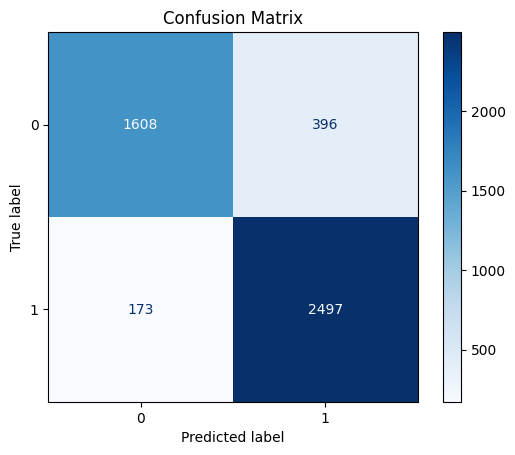

In [23]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
y_pred = model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')

plt.title("Confusion Matrix")
plt.show()

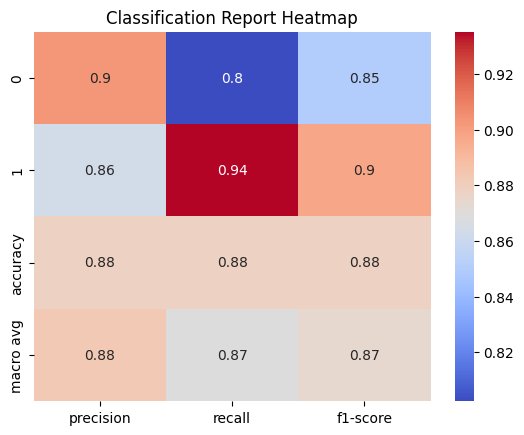

In [24]:
import seaborn as sns
from sklearn.metrics import classification_report
import pandas as pd

report = classification_report(y_test, y_pred, output_dict=True)
df = pd.DataFrame(report).transpose()

sns.heatmap(df.iloc[:-1, :-1], annot=True, cmap="coolwarm")
plt.title("Classification Report Heatmap")
plt.show()

In [25]:
plt.figure(figsize=(10,6))
plt.barh(features.columns, importance)
plt.title("Feature Importance (XGBoost)")
plt.xlabel("Importance Score")
plt.show()

NameError: name 'importance' is not defined